# Laboratorio: FrozenLake mediante Value Iteration

En este laboratorio resolveremos `FrozenLake-v1` **sin utilizar un algoritmo de aprendizaje de Stable-Baselines3**.

El objetivo es observar directamente cómo la ecuación de Bellman propaga el valor a través de los estados.

Trabajaremos con el ambiente **sin deslizamiento** (`is_slippery=False`). Por tanto, para cada par estado–acción existe una transición determinista:

$$
(s,a)\longrightarrow (s',r)
$$

El laboratorio tendrá cuatro etapas:

1. inspeccionar el ambiente y extraer sus transiciones;
2. construir \(Q(s,a)\) a partir de una función de valor \(V(s)\);
3. ejecutar **Value Iteration una iteración a la vez**;
4. visualizar sobre FrozenLake el valor de cada acción mediante cuatro regiones dentro de cada celda.

En cada celda utilizaremos:

- izquierda: $Q(s,\leftarrow)$
- abajo: $Q(s,\downarrow)$
- derecha: $Q(s,\rightarrow)$
- arriba: $Q(s,\uparrow)$

El color indicará qué tan valiosa resulta cada acción.

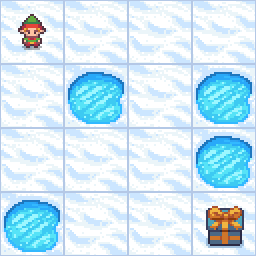

## 1. Instalación e importaciones

En Google Colab puede ser necesario instalar Gymnasium. El resto de las librerías utilizadas normalmente ya está disponible.

In [ ]:
!pip -q install "gymnasium[toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 51.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.colors import Normalize
import gymnasium as gym

## 2. Crear FrozenLake determinista

`FrozenLake-v1` representa un tablero formado por:

- `S`: estado inicial;
- `F`: superficie congelada transitable;
- `H`: hueco;
- `G`: meta.

Utilizaremos el mapa estándar de \(4\times4\).

La opción:

`is_slippery=False`

elimina el deslizamiento. Así, ejecutar una acción conduce siempre al mismo estado siguiente. Esto hace especialmente clara la relación entre el modelo del ambiente y Value Iteration.

In [ ]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)

desc = env.unwrapped.desc.astype(str)
desc

Número de estados: 16
Número de acciones: 4


array([['S', 'F', 'F', 'F'],
       ['F', 'H', 'F', 'H'],
       ['F', 'F', 'F', 'H'],
       ['H', 'F', 'F', 'G']], dtype='<U1')

## 3. Extraer el modelo de transición del ambiente

Value Iteration es un método **basado en modelo**: necesita conocer qué ocurre al ejecutar cada acción.

Gymnasium almacena la dinámica de FrozenLake en:

`env.unwrapped.P`

Para cada estado \(s\) y acción \(a\), allí encontramos transiciones con la forma:
$$
(p,s',r,\text{terminated})
$$

donde:

- $p$: probabilidad de la transición;
- $s'$: nuevo estado;
- $r$: recompensa inmediata;
- `terminated`: indica si el episodio terminó.

Como eliminamos el deslizamiento, cada estado–acción tendrá una única transición con probabilidad 1.

In [ ]:
ACTION_NAMES = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP",
}

P = env.unwrapped.P

for s in range(env.observation_space.n):
    print(f"Estado {s}")
    for a in range(env.action_space.n):
        print(f"  {ACTION_NAMES[a]:5s} -> {P[s][a]}")

Estado 0
  LEFT  -> [(1.0, 0, 0, False)]
  DOWN  -> [(1.0, 4, 0, False)]
  RIGHT -> [(1.0, 1, 0, False)]
  UP    -> [(1.0, 0, 0, False)]
Estado 1
  LEFT  -> [(1.0, 0, 0, False)]
  DOWN  -> [(1.0, 5, 0, True)]
  RIGHT -> [(1.0, 2, 0, False)]
  UP    -> [(1.0, 1, 0, False)]
Estado 2
  LEFT  -> [(1.0, 1, 0, False)]
  DOWN  -> [(1.0, 6, 0, False)]
  RIGHT -> [(1.0, 3, 0, False)]
  UP    -> [(1.0, 2, 0, False)]
Estado 3
  LEFT  -> [(1.0, 2, 0, False)]
  DOWN  -> [(1.0, 7, 0, True)]
  RIGHT -> [(1.0, 3, 0, False)]
  UP    -> [(1.0, 3, 0, False)]
Estado 4
  LEFT  -> [(1.0, 4, 0, False)]
  DOWN  -> [(1.0, 8, 0, False)]
  RIGHT -> [(1.0, 5, 0, True)]
  UP    -> [(1.0, 0, 0, False)]
Estado 5
  LEFT  -> [(1.0, 5, 0, True)]
  DOWN  -> [(1.0, 5, 0, True)]
  RIGHT -> [(1.0, 5, 0, True)]
  UP    -> [(1.0, 5, 0, True)]
Estado 6
  LEFT  -> [(1.0, 5, 0, True)]
  DOWN  -> [(1.0, 10, 0, False)]
  RIGHT -> [(1.0, 7, 0, True)]
  UP    -> [(1.0, 2, 0, False)]
Estado 7
  LEFT  -> [(1.0, 7, 0, True)]
  DOWN  -

### Construir una tabla determinista más sencilla

Para trabajar cómodamente extraeremos, para cada $(s,a)$:

- el estado siguiente;
- la recompensa;
- si la transición termina el episodio.

Aunque podríamos utilizar directamente `P`, esta tabla permite ver con claridad cuál es el modelo que Value Iteration utilizará.

In [ ]:
n_states = env.observation_space.n
n_actions = env.action_space.n

next_state = np.zeros((n_states, n_actions), dtype=int)
reward = np.zeros((n_states, n_actions), dtype=float)
terminated = np.zeros((n_states, n_actions), dtype=bool)

for s in range(n_states):
    for a in range(n_actions):
        transitions = P[s][a]

        if len(transitions) != 1:
            raise ValueError(
                "Se esperaba una única transición. "
                "Verifique que is_slippery=False."
            )

        prob, s_next, r, done = transitions[0]

        if not np.isclose(prob, 1.0):
            raise ValueError("La transición no es determinista.")

        next_state[s, a] = s_next
        reward[s, a] = r
        terminated[s, a] = done

print("Estados siguientes:")
print(next_state)

print("\nRecompensas inmediatas:")
print(reward)

Estados siguientes:
[[ 0  4  1  0]
 [ 0  5  2  1]
 [ 1  6  3  2]
 [ 2  7  3  3]
 [ 4  8  5  0]
 [ 5  5  5  5]
 [ 5 10  7  2]
 [ 7  7  7  7]
 [ 8 12  9  4]
 [ 8 13 10  5]
 [ 9 14 11  6]
 [11 11 11 11]
 [12 12 12 12]
 [12 13 14  9]
 [13 14 15 10]
 [15 15 15 15]]

Recompensas inmediatas:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]]


## 4. De $V(s)$ a la función $Q$

Value Iteration mantiene una estimación del valor de cada estado:

$$
V(s)
$$

Si conocemos \(V\), podemos calcular el valor de ejecutar una acción:

$$
Q(s,a)=r(s,a)+\gamma V(s')
$$

para una transición no terminal.

Si la acción termina el episodio, no existe recompensa futura que agregar:

$$
Q(s,a)=r(s,a)
$$

En FrozenLake determinista no necesitamos realizar la suma sobre todos los posibles estados siguientes porque cada acción conduce a uno solo.

Después calcularemos:

$$
V_{\text{nuevo}}(s)=\max_a Q(s,a)
$$

Esta es precisamente la actualización de Bellman para la política óptima.

In [ ]:
gamma = 0.95

V = np.zeros(n_states)

def compute_q(V, gamma=0.95):
    Q = np.zeros((n_states, n_actions), dtype=float)

    for s in range(n_states):
        for a in range(n_actions):
            r = reward[s, a]
            s_next = next_state[s, a]

            if terminated[s, a]:
                Q[s, a] = r
            else:
                Q[s, a] = r + gamma * V[s_next]

    return Q

Q = compute_q(V, gamma)

print("V inicial:")
print(V)

print("\nQ obtenido a partir de V=0:")
print(Q)

V inicial:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Q obtenido a partir de V=0:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]]


## 5. Visualizar \(Q(s,a)\) sobre FrozenLake

Dividiremos cada celda mediante sus dos diagonales. Así obtenemos cuatro triángulos, uno por acción.

La posición de cada triángulo corresponde físicamente a la acción:

- triángulo izquierdo: `LEFT`;
- triángulo inferior: `DOWN`;
- triángulo derecho: `RIGHT`;
- triángulo superior: `UP`.

Además del color, escribiremos el valor numérico de \(Q(s,a)\).

En el centro aparecerán el número del estado y el tipo de celda (`S`, `F`, `H` o `G`).

In [ ]:
def plot_q_values(Q, V=None, iteration=None, cmap="viridis"):
    rows, cols = desc.shape

    fig, ax = plt.subplots(figsize=(8, 8))

    q_min = float(np.min(Q))
    q_max = float(np.max(Q))

    # Evita una normalización degenerada cuando todos los valores son iguales.
    if np.isclose(q_min, q_max):
        q_min -= 0.5
        q_max += 0.5

    norm = Normalize(vmin=q_min, vmax=q_max)
    cm = plt.get_cmap(cmap)

    for row in range(rows):
        for col in range(cols):
            s = row * cols + col

            x0 = col
            x1 = col + 1
            y0 = rows - row - 1
            y1 = y0 + 1
            xc = col + 0.5
            yc = y0 + 0.5

            triangles = {
                0: [(x0, y0), (x0, y1), (xc, yc)],  # LEFT
                1: [(x0, y0), (x1, y0), (xc, yc)],  # DOWN
                2: [(x1, y0), (x1, y1), (xc, yc)],  # RIGHT
                3: [(x0, y1), (x1, y1), (xc, yc)],  # UP
            }

            text_positions = {
                0: (col + 0.16, yc),
                1: (xc, y0 + 0.16),
                2: (col + 0.84, yc),
                3: (xc, y0 + 0.84),
            }

            for a in range(n_actions):
                value = Q[s, a]
                patch = Polygon(
                    triangles[a],
                    closed=True,
                    facecolor=cm(norm(value)),
                    edgecolor="white",
                    linewidth=0.7,
                )
                ax.add_patch(patch)

                tx, ty = text_positions[a]
                ax.text(
                    tx, ty, f"{value:.2f}",
                    ha="center", va="center",
                    fontsize=7,
                )

            # Borde de la celda.
            ax.add_patch(
                Rectangle(
                    (x0, y0), 1, 1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5,
                )
            )

            cell = desc[row, col]
            center_text = f"{s}\n{cell}"
            if V is not None:
                center_text += f"\nV={V[s]:.2f}"

            ax.text(
                xc, yc, center_text,
                ha="center", va="center",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.8),
            )

    title = "FrozenLake — valores Q(s,a)"
    if iteration is not None:
        title += f" — iteración {iteration}"

    ax.set_title(title)
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label="Q(s,a)")

    plt.show()

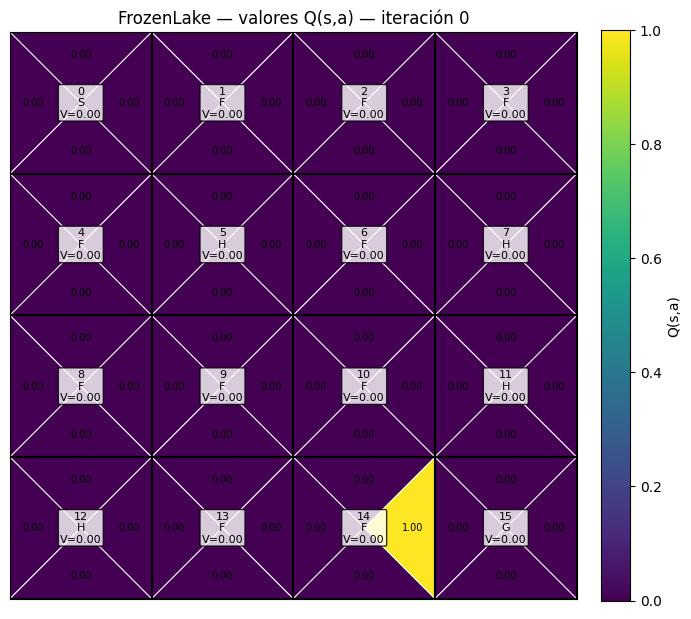

In [ ]:
plot_q_values(Q, V, iteration=0)

## 6. Una sola iteración de Value Iteration

Queremos poder observar el algoritmo paso a paso.

Una iteración realiza:

$$
Q_k(s,a)
=
r(s,a)+\gamma V_k(s')
$$

y posteriormente:

$$
V_{k+1}(s)
=
\max_a Q_k(s,a)
$$

Es importante distinguir los dos objetos:

- $Q_k(s,a)$ muestra el valor estimado de **cada decisión** usando $V_k$;
- $V_{k+1}(s)$ conserva la mejor de esas alternativas.

La siguiente función realiza exactamente **una iteración**.

In [ ]:
def value_iteration_step(V, gamma=0.95):
    Q = compute_q(V, gamma)
    V_new = np.max(Q, axis=1)

    # Los estados terminales no tienen decisiones futuras.
    terminal_states = [
        s for s in range(n_states)
        if desc.flat[s] in ("H", "G")
    ]
    V_new[terminal_states] = 0.0

    delta = np.max(np.abs(V_new - V))

    return V_new, Q, delta

### Reiniciar el algoritmo

Ejecute esta celda siempre que quiera comenzar nuevamente desde:

$$
V_0(s)=0
$$

Algoritmo reiniciado.


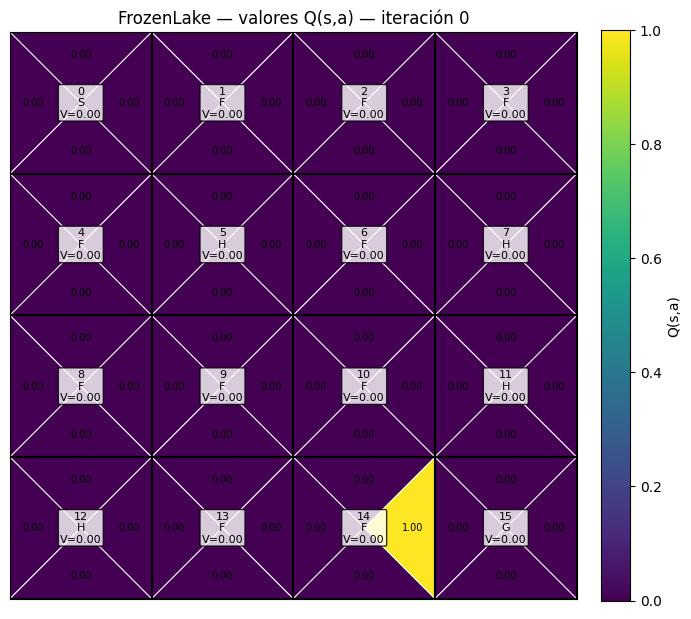

In [ ]:
V = np.zeros(n_states)
iteration = 0

Q = compute_q(V, gamma)

print("Algoritmo reiniciado.")
plot_q_values(Q, V, iteration)

### Ejecutar una iteración

Puede ejecutar repetidamente esta misma celda.

Cada ejecución avanzará **una iteración** y mostrará cómo los valores se propagan desde la meta hacia el resto del tablero.

Iteración: 1
Delta: 1.00000000

V:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]]


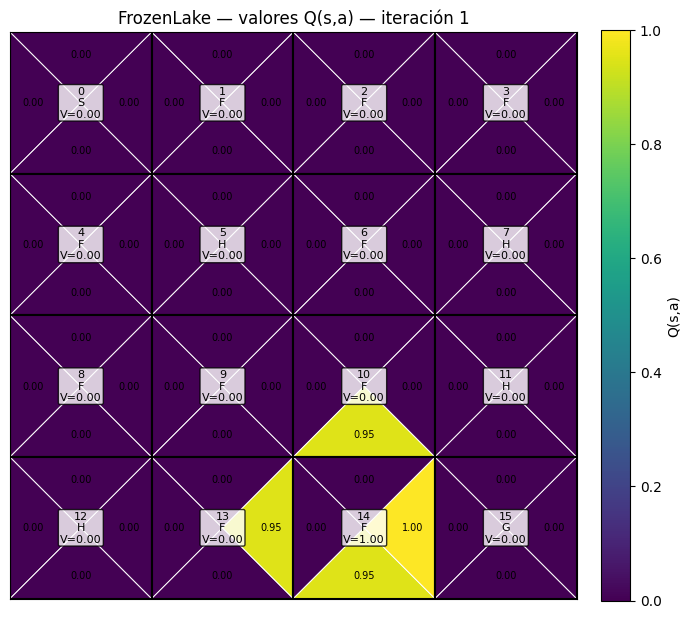

In [ ]:
V_new, Q_used, delta = value_iteration_step(V, gamma)

V = V_new
iteration += 1

# Q coherente con los valores ya actualizados, para visualizar el estado
# alcanzado después de esta iteración.
Q = compute_q(V, gamma)

print(f"Iteración: {iteration}")
print(f"Delta: {delta:.8f}")
print("\nV:")
print(V.reshape(desc.shape))

plot_q_values(Q, V, iteration)

## 7. Observar explícitamente la propagación

Al principio todos los estados tienen:

$$
V_0(s)=0
$$

La única acción con información positiva inmediata es aquella que entra directamente en `G`.

Después de la primera actualización, los estados vecinos a la meta adquieren valor. En iteraciones posteriores ese valor se propaga hacia estados cada vez más alejados.

Este fenómeno permite interpretar Value Iteration como una **propagación hacia atrás de las consecuencias futuras**.

## 8. Ejecutar varias iteraciones seguidas

Una vez comprendido el proceso paso a paso, podemos avanzar varias iteraciones automáticamente.

La función siguiente permite indicar cuántas iteraciones queremos realizar y, opcionalmente, dibujar cada una.

In [ ]:
def run_iterations(V, n=10, gamma=0.95, show_each=False, start_iteration=0):
    current_V = V.copy()
    current_iteration = start_iteration

    for _ in range(n):
        current_V, _, delta = value_iteration_step(current_V, gamma)
        current_iteration += 1

        if show_each:
            current_Q = compute_q(current_V, gamma)
            print(
                f"Iteración {current_iteration:3d} | "
                f"delta = {delta:.10f}"
            )
            plot_q_values(
                current_Q,
                current_V,
                current_iteration
            )

    return current_V, current_iteration

Iteración alcanzada: 6
[[0.77378094 0.81450625 0.857375   0.81450625]
 [0.81450625 0.         0.9025     0.        ]
 [0.857375   0.9025     0.95       0.        ]
 [0.         0.95       1.         0.        ]]


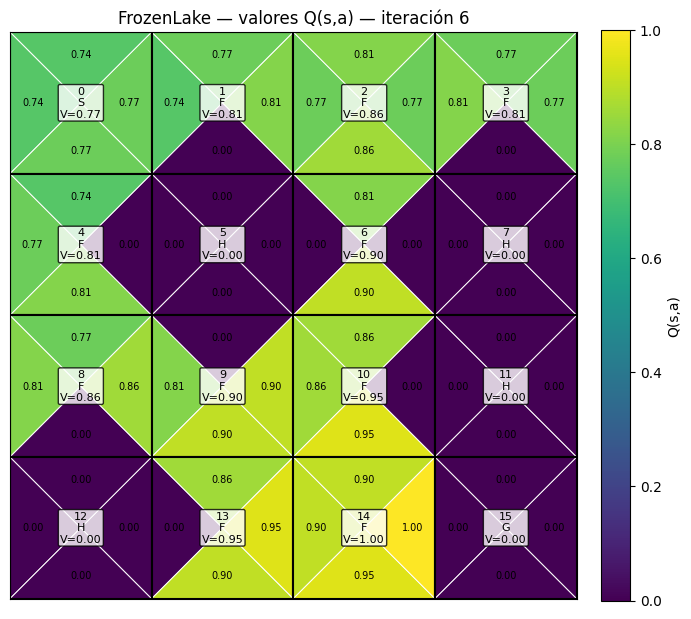

In [ ]:
# Ejemplo: avanzar 5 iteraciones desde el estado actual.
V, iteration = run_iterations(
    V,
    n=5,
    gamma=gamma,
    show_each=False,
    start_iteration=iteration
)

Q = compute_q(V, gamma)

print(f"Iteración alcanzada: {iteration}")
print(V.reshape(desc.shape))

plot_q_values(Q, V, iteration)

## 9. Resolver hasta convergencia

No es necesario decidir de antemano cuántas iteraciones ejecutar.

Podemos detener el algoritmo cuando:

$$
\max_s |V_{k+1}(s)-V_k(s)| < \theta
$$

Es decir, cuando una nueva iteración prácticamente no modifica los valores.

In [ ]:
def solve_value_iteration(gamma=0.95, theta=1e-10, max_iterations=10_000):
    V = np.zeros(n_states)

    history = []

    for k in range(1, max_iterations + 1):
        V_new, _, delta = value_iteration_step(V, gamma)

        history.append(delta)
        V = V_new

        if delta < theta:
            break

    Q = compute_q(V, gamma)

    return V, Q, k, np.array(history)

Convergencia después de 7 iteraciones

V*:
[[0.77378094 0.81450625 0.857375   0.81450625]
 [0.81450625 0.         0.9025     0.        ]
 [0.857375   0.9025     0.95       0.        ]
 [0.         0.95       1.         0.        ]]


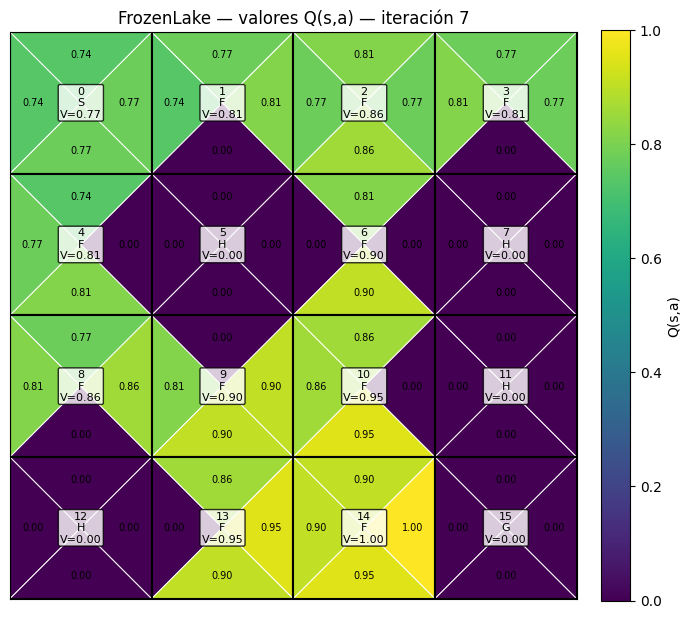

In [ ]:
V_star, Q_star, n_iter, history = solve_value_iteration(
    gamma=gamma,
    theta=1e-10
)

print(f"Convergencia después de {n_iter} iteraciones")
print("\nV*:")
print(V_star.reshape(desc.shape))

plot_q_values(Q_star, V_star, iteration=n_iter)

## 10. Extraer la política óptima

Una vez conocemos $Q^*(s,a)$, la política óptima se obtiene mediante:

$$
\pi^*(s)=\arg\max_a Q^*(s,a)
$$

Por tanto, para cada estado simplemente seleccionamos la acción con mayor valor.

In [ ]:
ARROWS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑",
}

policy = np.argmax(Q_star, axis=1)

policy_symbols = []

for s in range(n_states):
    cell = desc.flat[s]

    if cell == "H":
        policy_symbols.append("H")
    elif cell == "G":
        policy_symbols.append("G")
    else:
        policy_symbols.append(ARROWS[policy[s]])

policy_grid = np.array(policy_symbols).reshape(desc.shape)

print("Política óptima:")
print(policy_grid)

Política óptima:
[['↓' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '↓' '↓' 'H']
 ['H' '→' '→' 'G']]


## 11. Pintar la política sobre el tablero

Ahora resumiremos los cuatro valores de acción mediante una única flecha: la acción seleccionada por la política óptima.

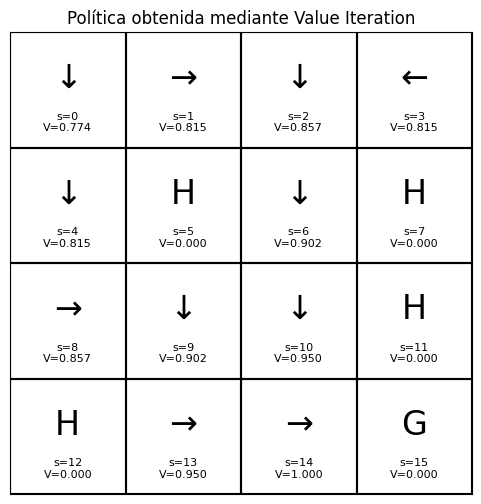

In [ ]:
def plot_policy(policy, V=None):
    rows, cols = desc.shape

    fig, ax = plt.subplots(figsize=(6, 6))

    for row in range(rows):
        for col in range(cols):
            s = row * cols + col

            x = col
            y = rows - row - 1
            cell = desc[row, col]

            ax.add_patch(
                Rectangle(
                    (x, y), 1, 1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5,
                )
            )

            if cell in ("H", "G"):
                symbol = cell
            else:
                symbol = ARROWS[policy[s]]

            ax.text(
                x + 0.5,
                y + 0.60,
                symbol,
                ha="center",
                va="center",
                fontsize=24,
            )

            text = f"s={s}"
            if V is not None:
                text += f"\nV={V[s]:.3f}"

            ax.text(
                x + 0.5,
                y + 0.22,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )

    ax.set_title("Política obtenida mediante Value Iteration")
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    plt.show()

plot_policy(policy, V_star)

## 12. Ejecutar la política en FrozenLake

Finalmente utilizaremos la política calculada para controlar el ambiente.

Observe que en esta etapa **ya no estamos aprendiendo**. Value Iteration terminó y produjo una política. Ahora simplemente la ejecutamos.

In [ ]:
obs, info = env.reset(seed=42)

trajectory = [obs]
total_reward = 0

terminated_episode = False
truncated = False

while not (terminated_episode or truncated):
    action = int(policy[obs])

    obs, r, terminated_episode, truncated, info = env.step(action)

    trajectory.append(obs)
    total_reward += r

print("Trayectoria:", trajectory)
print("Recompensa total:", total_reward)

Trayectoria: [0, 4, 8, 9, 13, 14, 15]
Recompensa total: 1


## 13. ¿Qué ocurrió?

Este laboratorio permite separar tres conceptos que posteriormente pueden confundirse cuando utilizamos librerías de Deep Reinforcement Learning.

### 1. El ambiente contiene el problema

FrozenLake define:

$$
S,\quad A,\quad P,\quad R
$$

En este caso pudimos acceder explícitamente al modelo de transición.

### 2. Value Iteration utiliza el modelo

Para cada estado y acción calculamos:

$$
Q(s,a)=\sum_{s'}
P(s'|s,a)\left[
R(s,a,s')+
\gamma V(s')\right]
$$

Como utilizamos un FrozenLake determinista, la suma se redujo a una única transición.

### 3. Bellman propaga el valor

Comenzamos con:

$$
V_0(s)=0
$$

y repetimos:

$$
V_{k+1}(s)=\max_a Q_k(s,a)
$$

La información acerca de la meta se fue propagando progresivamente hacia otros estados.

Finalmente obtuvimos:

$$
V^*(s)
$$

y:

$$
Q^*(s,a)
$$

de donde extraemos:

$$
\pi^*(s)=\arg\max_a Q^*(s,a)
$$

En el próximo paso podemos resolver **el mismo FrozenLake mediante Q-Learning**. Allí eliminaremos una pieza fundamental: el agente ya no utilizará explícitamente \(P(s'|s,a)\). Tendrá que descubrir los valores de las acciones mediante experiencia.